# Библиотеки и настройки

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../data/"
IMAGES_DIR = os.path.join(DATA_DIR, "images/")
MASKS_DIR = os.path.join(DATA_DIR, "masks/")
TRAIN_LIST = os.path.join(DATA_DIR, "train.txt")
CLS_LIST = os.path.join(DATA_DIR, "train_cls.txt")

img_ext = ".JPG"
mask_ext = ".PNG"

COLOR_MAP = {
    0: (0, 0, 0),      1: (0, 0, 64),     2: (0, 0, 128),
    3: (0, 64, 0),     4: (0, 128, 0),    5: (64, 0, 0),
    6: (64, 0, 64),    7: (64, 64, 0),    8: (64, 64, 64)
}


print("проект настроен, все загружено")

проект настроен, все загружено


# Проверка физического существования файлов

In [2]:
with open(TRAIN_LIST, "r") as f:
    train_ids = [line.strip() for line in f.readlines()]

missing_images = []
missing_masks = []

for file_id in train_ids:
    if not os.path.exists(os.path.join(IMAGES_DIR, file_id + img_ext)):
        missing_images.append(file_id)
    if not os.path.exists(os.path.join(MASKS_DIR, file_id + mask_ext)):
        missing_masks.append(file_id)

print(f"всего: {len(train_ids)}")
print(f"пропущено узи: {len(missing_images)}")
print(f"пропущено масок: {len(missing_masks)}")

if not missing_images and not missing_masks:
    print("все пары есть")

всего: 1000
пропущено узи: 0
пропущено масок: 0
все пары есть


# Анализ классификации

In [3]:
# 1. Читаем файл классификации
cls_path = "../data/train_cls.txt"

if os.path.exists(cls_path):
    with open(cls_path, "r") as f:
        lines = f.readlines()
        print(f"всего записей: {len(lines)}")
        print("\nпервые 10 строк")
        for line in lines[:10]:
            print(line.strip())
else:
    print("train_cls.txt не найден")

всего записей: 1000

первые 10 строк
658.JPG  5
384.JPG  3
367.JPG  3
730.JPG  1
1426.JPG  7
1194.JPG  6
232.JPG  2
997.JPG  2
1151.JPG  3
840.JPG  2


Визуализация примеров

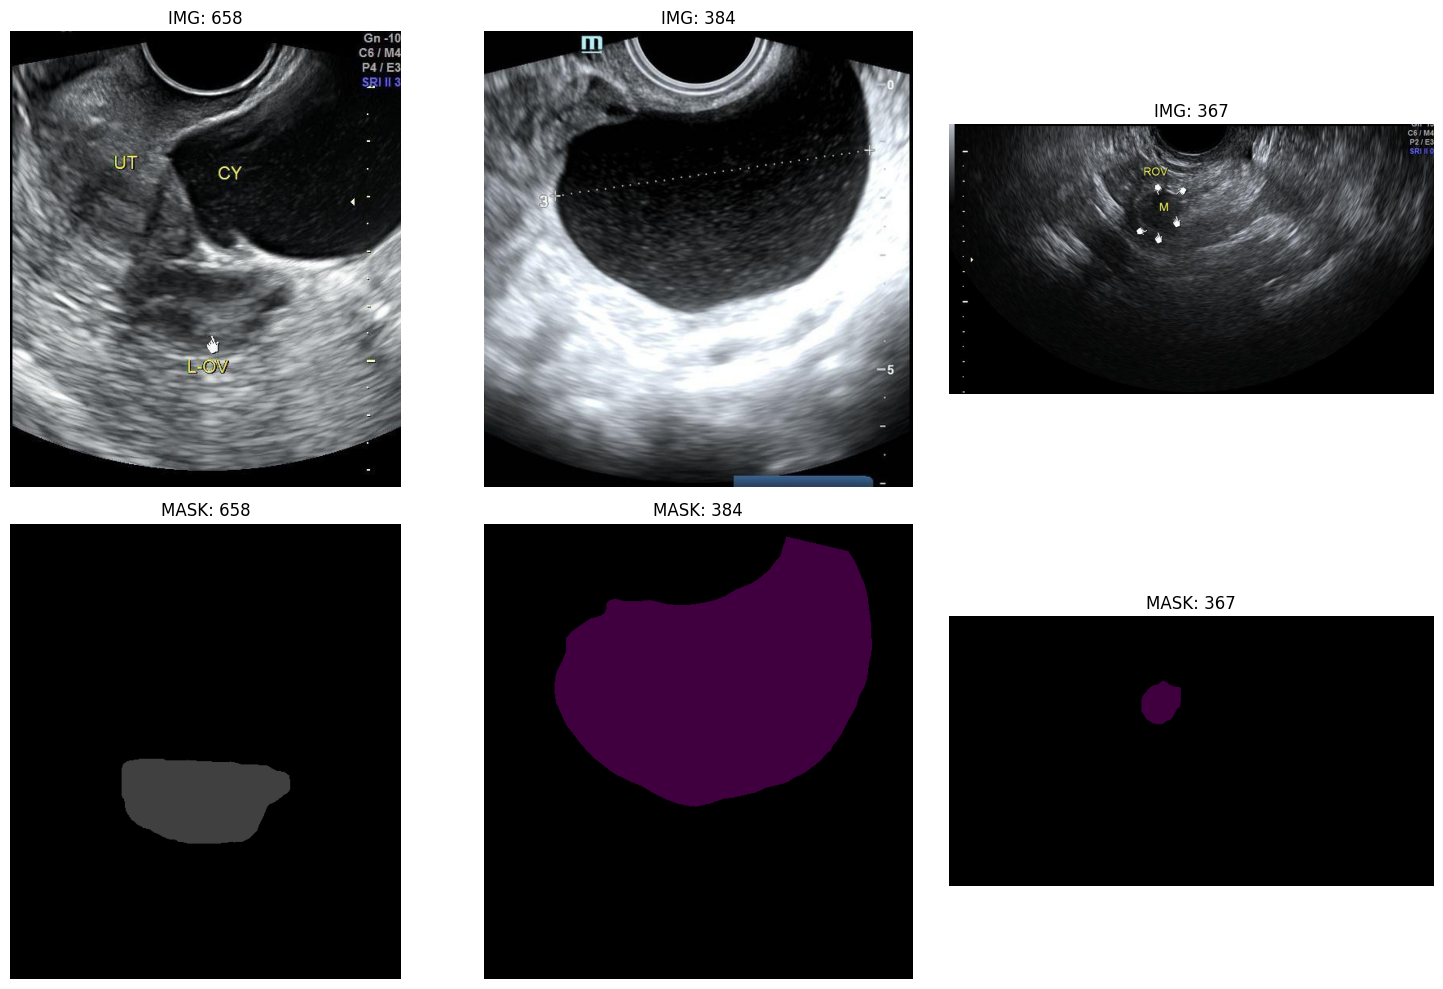

In [4]:
sample_ids = train_ids[:3]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, file_id in enumerate(sample_ids):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMAGES_DIR, file_id + img_ext)), cv2.COLOR_BGR2RGB)
    mask = cv2.cvtColor(cv2.imread(os.path.join(MASKS_DIR, file_id + mask_ext)), cv2.COLOR_BGR2RGB)
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"IMG: {file_id}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask)
    axes[1, i].set_title(f"MASK: {file_id}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Проверка синхронизаци

c:\Users\Екатерина\Desktop\ovarian_ml-main\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


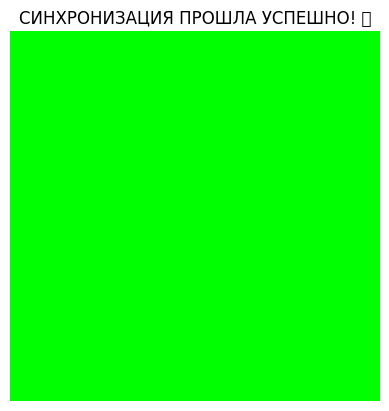

In [5]:

#ТЕСТ СИНХРОНИЗАЦИИ
import matplotlib.pyplot as plt
import numpy as np

def check_sync():
    # Создаем маленький зеленый квадрат
    test_img = np.zeros((100, 100, 3), dtype=np.uint8)
    test_img[:, :, 1] = 255 # Закрашиваем зеленым цветом
    
    plt.imshow(test_img)
    plt.title("СИНХРОНИЗАЦИЯ ПРОШЛА УСПЕШНО! 🚀")
    plt.axis('off')
    plt.show()

check_sync()